## Boilerplate

In [1]:
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.25)

In [3]:
import medmnist
from medmnist import INFO, Evaluator

In [4]:
# Import local files
%load_ext autoreload
%autoreload 2
from bcnn_training import *
from cnn_training import get_semi_supervised_labels, SSLDataset
from plots import *
from variational_cnn import *
from constants import *

In [5]:
data_flag = 'dermamnist'
download = True

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

In [6]:
# Note: this preprocesses data such that it has mean 0.5 and std dev 0.5.
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
val_dataset = DataClass(split='val', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

BATCH_SIZE = 128

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
# train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

In [7]:
def default_setup(lr=0.001, l2_weight=0.0, rho_init=-2.25):
    model = VariationalCNN(n_channels, n_classes, rho_init=rho_init)
    # criterion = nn.CrossEntropyLoss(weight=class_weights)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=l2_weight)
    return model, criterion, optimizer

In [8]:
RANDOM_SEED = 42

## try it on 50% unlabeled

In [28]:
# Create SSL versions of our datasets
unlabeled_rate = 0.5

train_labels_ssl_50 = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset_50 = SSLDataset(train_dataset, train_labels_ssl_50)
train_ssl_loader_50 = data.DataLoader(train_ssl_dataset_50, batch_size=BATCH_SIZE, shuffle=True)

Unlabeled rate: 0.5 | Total examples: 7007 | Labeled examples: 3506 | Unlabeled examples: 3501
Class 0: 114/228 labeled, 114 unlabeled
Class 1: 180/359 labeled, 179 unlabeled
Class 2: 385/769 labeled, 384 unlabeled
Class 3: 40/80 labeled, 40 unlabeled
Class 4: 390/779 labeled, 389 unlabeled
Class 5: 2347/4693 labeled, 2346 unlabeled
Class 6: 50/99 labeled, 49 unlabeled


In [29]:
# Import local files
%load_ext autoreload
%autoreload 2
from bcnn_training import *
from cnn_training import get_semi_supervised_labels, SSLDataset
from plots import *
from variational_cnn import *
from constants import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
upgrade_model_50, criterion, optimizer = default_setup()
upgrade_history_50 = train_loop_bcnn_soft_pseudo_label(upgrade_model_50, train_ssl_loader_50, val_loader, criterion, optimizer, num_epochs=20, alpha=0.1, beta=1.0, num_samples=10)

  0%|          | 0/55 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:01<00:00,  4.41it/s]


Epoch 1/20 | Train NLL: 1.4688 | Train KL (avg/batch): 0.9019 | Unlabeled Examples Used: 3501/3501 | Train Loss Unlabeled: 1.4001 | Val AUC Macro: 0.5089 | Val AUC Global: 0.8697


100%|██████████| 8/8 [00:01<00:00,  4.35it/s]


Epoch 2/20 | Train NLL: 1.3245 | Train KL (avg/batch): 0.9017 | Unlabeled Examples Used: 3501/3501 | Train Loss Unlabeled: 1.4033 | Val AUC Macro: 0.4989 | Val AUC Global: 0.8735


...

Epoch 18/20 | Train NLL: 0.9059 | Train KL (avg/batch): 0.8947 | Unlabeled Examples Used: 3501/3501 | Train Loss Unlabeled: 0.9905 | Val AUC Macro: 0.8233 | Val AUC Global: 0.9320


100%|██████████| 8/8 [00:01<00:00,  4.18it/s]


Epoch 19/20 | Train NLL: 0.9112 | Train KL (avg/batch): 0.8940 | Unlabeled Examples Used: 3501/3501 | Train Loss Unlabeled: 0.9447 | Val AUC Macro: 0.8172 | Val AUC Global: 0.9326


100%|██████████| 8/8 [00:01<00:00,  4.21it/s]


Epoch 20/20 | Train NLL: 0.9009 | Train KL (avg/batch): 0.8934 | Unlabeled Examples Used: 3501/3501 | Train Loss Unlabeled: 0.9535 | Val AUC Macro: 0.8355 | Val AUC Global: 0.9314


In [32]:
best_upgrade_50_history = max(upgrade_history_50, key=lambda x: x['val_auc_macro'])
print(f"Best Epoch: {best_upgrade_50_history['epoch']} | Val AUC Macro: {best_upgrade_50_history['val_auc_macro']:.4f}")

best_upgrade_model_50 = VariationalCNN(n_channels, n_classes)
best_upgrade_model_50.load_state_dict(best_upgrade_50_history['model_state'])

Best Epoch: 17 | Val AUC Macro: 0.8359


<All keys matched successfully>

In [33]:
test_results_upgrade_50 = evaluate_bayesian(best_upgrade_model_50, test_loader, device='cpu')
test_results_upgrade_50

  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:05<00:00,  1.45it/s]

preds: [5 1 5 ... 5 5 5]


{'macro_auc': 0.8258242433076036,
 'global_auc': 0.9320157420248216,
 'nll': np.float32(0.92536724),
 'per_class_auc': [0.8656055136199541,
  0.8540626627055832,
  0.8240285204991088,
  0.8639275216075111,
  0.7903952328466529,
  0.8468504892051426,
  0.7358997626692727],
 'confusion_matrix': array([[0.        , 0.01515152, 0.24242424, 0.        , 0.        ,
         0.74242424, 0.        ],
        [0.        , 0.00970874, 0.11650485, 0.        , 0.        ,
         0.87378641, 0.        ],
        [0.        , 0.00454545, 0.15      , 0.        , 0.        ,
         0.84545455, 0.        ],
        [0.        , 0.04347826, 0.17391304, 0.        , 0.        ,
         0.7826087 , 0.        ],
        [0.        , 0.0044843 , 0.03139013, 0.        , 0.        ,
         0.96412556, 0.        ],
        [0.        , 0.        , 0.00894855, 0.        , 0.        ,
         0.99105145, 0.        ],
        [0.        , 0.        , 0.06896552, 0.        , 0.        ,
         0.93103448,

In [34]:
with torch.no_grad():
    best_upgrade_model_50.eval()
    probs, targets = [], []
    for images, labels in tqdm(test_loader):
        images = images.to('cpu')
        mean_probs = best_upgrade_model_50.average_probs(images, num_samples=10)
        probs.append(mean_probs.cpu().numpy())
        targets.append(labels.squeeze().cpu().numpy())

probs = np.concatenate(probs)
targets = np.concatenate(targets)
preds = np.argmax(probs, axis=1)
print(f"Percentage of predictions that are class 5: {(preds == 5).mean() * 100:.1f}%")

  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:02<00:00,  2.90it/s]

Percentage of predictions that are class 5: 95.9%


In [35]:
best_upgrade_model_50.eval()
all_pseudo_labels = []
with torch.no_grad():
    for images, labels in train_ssl_loader_50:
        unlabeled_mask = (labels == -1).squeeze()
        inputs_unlabeled = images[unlabeled_mask]
        if inputs_unlabeled.size(0) > 0:
            avg_probs = best_upgrade_model_50.average_probs(inputs_unlabeled, num_samples=10)
            all_pseudo_labels.append(avg_probs)

all_pseudo_labels = torch.cat(all_pseudo_labels)
print(f"Mean pseudo-label distribution: {all_pseudo_labels.mean(dim=0).numpy()}")

Mean pseudo-label distribution: [0.03767184 0.05260856 0.11844113 0.01231024 0.14928885 0.61327684
 0.01640252]


In [36]:
print(f"Mean predicted distribution: {probs.mean(axis=0)}")
print(f"Mean max probability: {probs.max(axis=1).mean():.3f}")

Mean predicted distribution: [0.03766195 0.05263411 0.12192594 0.01248506 0.14488326 0.61344576
 0.01696391]
Mean max probability: 0.615


In [40]:
# Create SSL versions of our datasets
unlabeled_rate = 0.0

train_labels_ssl_00 = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset_00 = SSLDataset(train_dataset, train_labels_ssl_00)
train_ssl_loader_00 = data.DataLoader(train_ssl_dataset_00, batch_size=BATCH_SIZE, shuffle=True)

Unlabeled rate: 0.0 | Total examples: 7007 | Labeled examples: 7007 | Unlabeled examples: 0
Class 0: 228/228 labeled, 0 unlabeled
Class 1: 359/359 labeled, 0 unlabeled
Class 2: 769/769 labeled, 0 unlabeled
Class 3: 80/80 labeled, 0 unlabeled
Class 4: 779/779 labeled, 0 unlabeled
Class 5: 4693/4693 labeled, 0 unlabeled
Class 6: 99/99 labeled, 0 unlabeled


In [38]:
best_upgrade_model_50.eval()
class_probs = [[] for _ in range(7)]
with torch.no_grad():
    for images, labels in train_ssl_loader_00:
        avg_probs = best_upgrade_model_50.average_probs(images, num_samples=10)
        for i in range(7):
            mask = (labels.squeeze() == i)
            if mask.sum() > 0:
                class_probs[i].append(avg_probs[mask])

for i in range(7):
    if class_probs[i]:
        mean_dist = torch.cat(class_probs[i]).mean(dim=0).numpy()
        print(f"Class {i}: {np.round(mean_dist, 3)}")

Class 0: [0.099 0.141 0.218 0.031 0.125 0.363 0.023]
Class 1: [0.098 0.139 0.217 0.031 0.128 0.362 0.024]
Class 2: [0.073 0.104 0.197 0.022 0.167 0.417 0.02 ]
Class 3: [0.098 0.142 0.204 0.031 0.122 0.378 0.025]
Class 4: [0.037 0.051 0.14  0.011 0.204 0.541 0.016]
Class 5: [0.027 0.036 0.091 0.009 0.133 0.688 0.015]
Class 6: [0.053 0.069 0.132 0.017 0.13  0.58  0.02 ]


#### Even after converting back to fully labeled dataset, we sorta collapse to the majority class?

## what about fully supervised again? without pseudo labels

In [59]:
# Import local files
%load_ext autoreload
%autoreload 2
from bcnn_training import *
from cnn_training import get_semi_supervised_labels, SSLDataset
from plots import *
from variational_cnn import *
from constants import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
# Create SSL versions of our datasets
unlabeled_rate = 0.0

train_labels_ssl_00 = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset_00 = SSLDataset(train_dataset, train_labels_ssl_00)
train_ssl_loader_00 = data.DataLoader(train_ssl_dataset_00, batch_size=BATCH_SIZE, shuffle=True)

Unlabeled rate: 0.0 | Total examples: 7007 | Labeled examples: 7007 | Unlabeled examples: 0
Class 0: 228/228 labeled, 0 unlabeled
Class 1: 359/359 labeled, 0 unlabeled
Class 2: 769/769 labeled, 0 unlabeled
Class 3: 80/80 labeled, 0 unlabeled
Class 4: 779/779 labeled, 0 unlabeled
Class 5: 4693/4693 labeled, 0 unlabeled
Class 6: 99/99 labeled, 0 unlabeled


In [61]:
upgrade_model_00, criterion, optimizer = default_setup(rho_init=-6.0)
upgrade_history_00 = train_loop_bcnn_soft_pseudo_label(upgrade_model_00, train_ssl_loader_00, val_loader, criterion, optimizer, num_epochs=30, alpha=0.5, beta=0.0, num_samples=10)

100%|██████████| 8/8 [00:01<00:00,  4.29it/s]


Epoch 1/30 | Train NLL: 0.9014 | Train KL (avg/batch): 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 0.8064 | Train Loss Unlabeled: 0.0000 | Val AUC Macro: 0.8813 | Val AUC Global: 0.9463


100%|██████████| 8/8 [00:01<00:00,  4.36it/s]


Epoch 2/30 | Train NLL: 0.7650 | Train KL (avg/batch): 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 0.7425 | Train Loss Unlabeled: 0.0000 | Val AUC Macro: 0.9000 | Val AUC Global: 0.9544


100%|██████████| 8/8 [00:01<00:00,  4.36it/s]


...

Epoch 28/30 | Train NLL: 0.0525 | Train KL (avg/batch): 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 1.3972 | Train Loss Unlabeled: 0.0000 | Val AUC Macro: 0.8852 | Val AUC Global: 0.9420


100%|██████████| 8/8 [00:01<00:00,  4.14it/s]


Epoch 29/30 | Train NLL: 0.0307 | Train KL (avg/batch): 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 1.4956 | Train Loss Unlabeled: 0.0000 | Val AUC Macro: 0.8983 | Val AUC Global: 0.9432


100%|██████████| 8/8 [00:01<00:00,  4.12it/s]

Epoch 30/30 | Train NLL: 0.0364 | Train KL (avg/batch): 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 1.5118 | Train Loss Unlabeled: 0.0000 | Val AUC Macro: 0.8941 | Val AUC Global: 0.9435


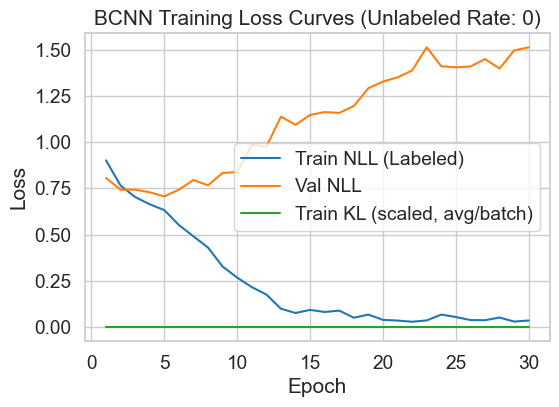

In [62]:
plot_loss_curves_bcnn(upgrade_history_00)

In [63]:
print(f'train nll: {[h["train_nll_labeled"] for h in upgrade_history_00]}')
print(f'val nll: {[h["val_loss"] for h in upgrade_history_00]}')

train nll: [0.9014225639833505, 0.7649568892229602, 0.7032860384716259, 0.6640619500839916, 0.6327793260214076, 0.5522217303876005, 0.4908442068443636, 0.43027781754140937, 0.3276720127255358, 0.26799278393381415, 0.2168756312564009, 0.17690523978696496, 0.10004398000679258, 0.07695409625266782, 0.0937019283388172, 0.08248657825603216, 0.08978049681855962, 0.051559464367213155, 0.06835042178392649, 0.03986493323651687, 0.03609569537313396, 0.029661621090699378, 0.03686809433730213, 0.06837808474658032, 0.05526485226902724, 0.038797391350741936, 0.038152063863817934, 0.05254049759729793, 0.030650648988482444, 0.03641757275895894]
val nll: [0.806372571859141, 0.7425181031940228, 0.7431962126986693, 0.7289695849090606, 0.706621285865932, 0.7432661786868588, 0.7953813288171413, 0.7666279407346237, 0.8337437501576462, 0.8379390629552536, 0.9845426306054219, 0.9751552695172615, 1.1375254973813758, 1.0932749074810404, 1.1468292850321335, 1.1621821255294063, 1.1578813490577613, 1.1946517753220

In [64]:
best_upgrade_00_history = max(upgrade_history_00, key=lambda x: x['val_auc_macro'])
print(f"Best Epoch: {best_upgrade_00_history['epoch']} | Val AUC Macro: {best_upgrade_00_history['val_auc_macro']:.4f}")

best_upgrade_model_00 = VariationalCNN(n_channels, n_classes)
best_upgrade_model_00.load_state_dict(best_upgrade_00_history['model_state'])

Best Epoch: 5 | Val AUC Macro: 0.9186


<All keys matched successfully>

In [65]:
test_results_upgrade_00 = evaluate_bayesian(best_upgrade_model_00, test_loader, device='cpu')
test_results_upgrade_00

100%|██████████| 8/8 [00:05<00:00,  1.37it/s]

preds: [5 5 2 ... 5 5 5]


{'macro_auc': 0.9086800858868636,
 'global_auc': 0.9584640228190953,
 'nll': np.float32(0.7176928),
 'per_class_auc': [0.9365808679888101,
  0.9312731616183272,
  0.8823198370257194,
  0.8993331285921116,
  0.851642986919519,
  0.9073385263649676,
  0.9522720926985899],
 'confusion_matrix': array([[3.18181818e-01, 2.72727273e-01, 1.06060606e-01, 0.00000000e+00,
         4.54545455e-02, 2.57575758e-01, 0.00000000e+00],
        [5.82524272e-02, 4.27184466e-01, 9.70873786e-02, 0.00000000e+00,
         2.91262136e-02, 3.00970874e-01, 8.73786408e-02],
        [3.63636364e-02, 5.90909091e-02, 3.50000000e-01, 0.00000000e+00,
         7.27272727e-02, 4.81818182e-01, 0.00000000e+00],
        [8.69565217e-02, 2.60869565e-01, 4.34782609e-02, 0.00000000e+00,
         4.34782609e-02, 5.65217391e-01, 0.00000000e+00],
        [1.79372197e-02, 2.24215247e-02, 1.03139013e-01, 0.00000000e+00,
         1.61434978e-01, 6.81614350e-01, 1.34529148e-02],
        [7.45712155e-04, 6.71140940e-03, 1.41685309e-0

In [66]:
with torch.no_grad():
    best_upgrade_model_00.eval()
    probs, targets = [], []
    for images, labels in tqdm(test_loader):
        images = images.to('cpu')
        mean_probs = best_upgrade_model_00.average_probs(images, num_samples=10)
        probs.append(mean_probs.cpu().numpy())
        targets.append(labels.squeeze().cpu().numpy())

probs = np.concatenate(probs)
targets = np.concatenate(targets)
preds = np.argmax(probs, axis=1)
print(f"Percentage of predictions that are class 5: {(preds == 5).mean() * 100:.1f}%")

100%|██████████| 8/8 [00:02<00:00,  2.75it/s]

Percentage of predictions that are class 5: 81.1%


In [67]:
best_upgrade_model_00.eval()
class_probs = [[] for _ in range(7)]
with torch.no_grad():
    for images, labels in train_ssl_loader_00:
        avg_probs = best_upgrade_model_00.average_probs(images, num_samples=10)
        for i in range(7):
            mask = (labels.squeeze() == i)
            if mask.sum() > 0:
                class_probs[i].append(avg_probs[mask])

for i in range(7):
    if class_probs[i]:
        mean_dist = torch.cat(class_probs[i]).mean(dim=0).numpy()
        print(f"Class {i}: {np.round(mean_dist, 3)}")

Class 0: [0.305 0.196 0.158 0.032 0.08  0.213 0.016]
Class 1: [0.106 0.41  0.101 0.03  0.046 0.242 0.064]
Class 2: [0.055 0.062 0.347 0.013 0.109 0.398 0.014]
Class 3: [0.141 0.189 0.148 0.061 0.05  0.389 0.022]
Class 4: [0.036 0.039 0.087 0.005 0.301 0.507 0.025]
Class 5: [0.005 0.01  0.029 0.002 0.044 0.901 0.008]
Class 6: [0.016 0.061 0.016 0.007 0.051 0.232 0.618]


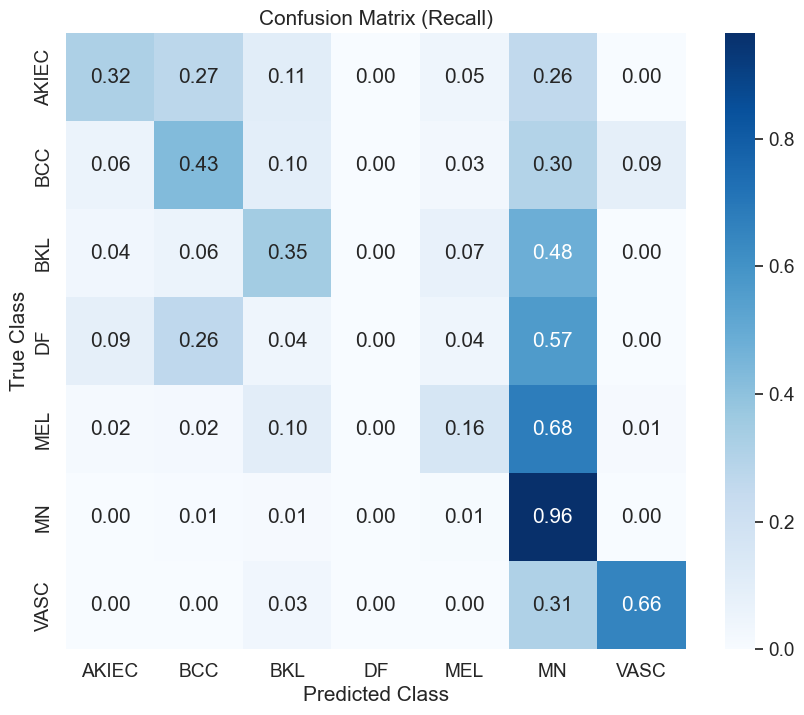

In [68]:
plot_per_class_recall(test_results_upgrade_00['confusion_matrix'], list(short_labels.values()))

## What does this tell us? above was run with rho_init=-6, ie a much smaller variance for the weights. 

In [71]:
F.softplus(torch.tensor(-6.0))

tensor(0.0025)

So with rho_init = -6, our standard deviation for the weights at the start of training is 0.0025. I feel like this is so tiny that our weights are basically point estimates? But maybe the scale matters here, like if our weights are all really tiny then that could be a reasonable setting for stddev.